In [9]:
from texttable import Texttable

# Initialize the table
table = Texttable()

# Define the table headers and rows
table.header(["Category", "Details"])
table.add_rows([
    ["Naive Bayes Model with One-Hot vectors and Unigram+Bigram", ""],
    ["Type of Smoothing Used?", "OVER SAMPLING"],
    ["Config of model trained?", "YES"],
    ["Train Time = ?", "0.3944 seconds"],
    ["Training Data Check", "YES"],
    ["Confusion Matrix Built?", "YES"],
    ["F1 Score for Positive = ?", "0.9103"],
    ["F1 Score for Negative = ?", "0.9103"],
    ["AUC plotted?", "YES"],
    ["AUC = ?", "0.9393"],
    ["Accuracy computed?", "YES"],
    ["Accuracy = ?", "0.905025"],
    ["Feature Engg", "YES"],
    ["Feature Weightages Added?", "YES"],
    ["2 Features with the Highest Weights?", "(3.719248949015009, 'wow ed'), (3.631047779039765, 'pimento cheese')"],
    ["Cross Validation", "YES"],
    ["Type of Cross Validation performed?", "K-FOLD"],
    ["Testing Data Check", "YES"],
    ["Confusion Matrix Built?", "YES"],
    ["F1 Score for Positive = ?", " 0.81645"],
    ["F1 Score for Negative = ?", " 0.81645"],
    ["AUC plotted?", "YES"],
    ["AUC = ?", "0.8537"],
    ["Accuracy computed?", "YES"],
    ["Accuracy = ?", "0.8003"],
    ])

# Print the table
print(table.draw())

+---------------------------------------+--------------------------------------+
|    Naive Bayes Model with One-Hot     |                                      |
|      vectors and Unigram+Bigram       |                                      |
+=======================================+======================================+
| Type of Smoothing Used?               | OVER SAMPLING                        |
+---------------------------------------+--------------------------------------+
| Config of model trained?              | YES                                  |
+---------------------------------------+--------------------------------------+
| Train Time = ?                        | 0.3944 seconds                       |
+---------------------------------------+--------------------------------------+
| Training Data Check                   | YES                                  |
+---------------------------------------+--------------------------------------+
| Confusion Matrix Built?   

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    accuracy_score, 
    roc_curve, 
    auc,
    f1_score
)
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import matplotlib.pyplot as plt
import emoji
from imblearn.over_sampling import SMOTE
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer

## Load and Preprocess Dataset

In [2]:
file_path = r'C:\Users\COMFORT\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_review.json'
df = pd.read_json(file_path, lines=True, nrows=100000)

In [3]:
# Initialize stemmer and lemmatizer
ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Define a function for preprocessing text with stemming and lemmatization
def preprocess_text_with_stemming_lemmatization(text, use_stemming=False, use_lemmatization=False):
    text = re.sub(r'\W', ' ', str(text))  # Remove special characters
    text = re.sub(r'\s+', ' ', text)      # Replace multiple spaces with a single space
    text = text.lower()                   # Convert to lowercase
    text = re.sub(r'#\S+', '', text)      # Remove hashtags (optional for feature selection)
    text = emoji.demojize(text)           # Convert emojis to text (e.g., 😀 -> :grinning_face:)
    
    if use_stemming:
        text = ' '.join([ps.stem(word) for word in text.split()])
    elif use_lemmatization:
        text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])
        
    return text

# Apply label transformation based on 'stars' column
df['label'] = df['stars'].apply(lambda x: 'Positive' if x >= 4 else ('Negative' if x <= 2 else 'Neutral'))

# Encode the labels as numeric values
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Apply enhanced text cleaning with stemming or lemmatization
df['cleaned_text_stemmed'] = df['text'].apply(lambda x: preprocess_text_with_stemming_lemmatization(x, use_stemming=True))
df['cleaned_text_lemmatized'] = df['text'].apply(lambda x: preprocess_text_with_stemming_lemmatization(x, use_lemmatization=True))

In [4]:
df['label'] = df['stars'].apply(lambda x: 'Positive' if x >= 4 else ('Negative' if x <= 2 else 'Neutral'))
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

## Train-Test Split

In [5]:
# Train-Test Split
X = df['cleaned_text_lemmatized']  
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## TF-IDF Vectorization (Unigram + Bigram)

In [6]:
# TF-IDF Vectorization (Unigram + Bigram)
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_df=0.8, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Handle Class Imbalance with SMOTE

In [7]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

## GridSearchCV for Naive Bayes

In [8]:
# Naive Bayes Model with GridSearchCV
nb = MultinomialNB()
param_grid = {'alpha': [0.5, 1.0]}
grid_search = GridSearchCV(nb, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_resampled, y_train_resampled)
best_nb = grid_search.best_estimator_

## Train and Predict

In [9]:
start_time = time.time()

# Train the model with resampled data
best_nb.fit(X_train_resampled, y_train_resampled)

end_time = time.time()

# Calculate training time
train_time = end_time - start_time

# Print the training time
print(f"Training Time: {train_time:.4f} seconds")

# Make predictions on the test and training sets
y_pred = best_nb.predict(X_test_tfidf)
y_train_pred = best_nb.predict(X_train_tfidf)


Training Time: 0.3944 seconds


## Metrics and Evaluation

In [10]:
# Function to print metrics for train and test sets
def print_metrics(y_train, y_train_pred, y_test, y_pred):
    # --- For Train Set ---
    print("\nMetrics for Train Set:")

    # Confusion Matrix for Train Set
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    print("\nConfusion Matrix (Train Set):")
    print(conf_matrix_train)

    # Classification Report for Train Set
    print("\nClassification Report (Train Set):")
    print(classification_report(y_train, y_train_pred))

    # Accuracy for Train Set
    accuracy_train = accuracy_score(y_train, y_train_pred)
    print("\nAccuracy (Train Set):", accuracy_train)

    # AUC Score for Train Set
    encoder = OneHotEncoder(sparse=False)
    y_train_encoded = encoder.fit_transform(np.array(y_train).reshape(-1, 1))
    y_train_pred_encoded = encoder.transform(np.array(y_train_pred).reshape(-1, 1))
    roc_auc_train = roc_auc_score(y_train_encoded, y_train_pred_encoded, average='weighted', multi_class='ovr')
    print("\nAUC Score (Train Set):", roc_auc_train)

    # F1 Scores for Positive and Negative Classes for Train Set
    f1_positive_train = f1_score(y_train, y_train_pred, pos_label='Positive', average='weighted')
    f1_negative_train = f1_score(y_train, y_train_pred, pos_label='Negative', average='weighted')
    print("\nF1 Score for Positive Class (Train Set):", f1_positive_train)
    print("F1 Score for Negative Class (Train Set):", f1_negative_train)

    # --- For Test Set ---
    print("\nMetrics for Test Set:")

    # Confusion Matrix for Test Set
    conf_matrix_test = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix (Test Set):")
    print(conf_matrix_test)

    # Classification Report for Test Set
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred))

    # Accuracy for Test Set
    accuracy_test = accuracy_score(y_test, y_pred)
    print("\nAccuracy (Test Set):", accuracy_test)

    # AUC Score for Test Set
    y_test_encoded = encoder.fit_transform(np.array(y_test).reshape(-1, 1))
    y_pred_encoded = encoder.transform(np.array(y_pred).reshape(-1, 1))
    roc_auc_test = roc_auc_score(y_test_encoded, y_pred_encoded, average='weighted', multi_class='ovr')
    print("\nAUC Score (Test Set):", roc_auc_test)

    # F1 Scores for Positive and Negative Classes for Test Set
    f1_positive_test = f1_score(y_test, y_pred, pos_label='Positive', average='weighted')
    f1_negative_test = f1_score(y_test, y_pred, pos_label='Negative', average='weighted')
    print("\nF1 Score for Positive Class (Test Set):", f1_positive_test)
    print("F1 Score for Negative Class (Test Set):", f1_negative_test)

# Call the function to print metrics for both train and test sets
print_metrics(y_train, y_train_pred, y_test, y_pred)


Metrics for Train Set:

Confusion Matrix (Train Set):
[[13665  1318   164]
 [  557  8294   236]
 [ 1874  3449 50443]]

Classification Report (Train Set):
              precision    recall  f1-score   support

           0       0.85      0.90      0.87     15147
           1       0.64      0.91      0.75      9087
           2       0.99      0.90      0.95     55766

    accuracy                           0.91     80000
   macro avg       0.83      0.91      0.86     80000
weighted avg       0.92      0.91      0.91     80000


Accuracy (Train Set): 0.905025

AUC Score (Train Set): 0.9393931369093854

F1 Score for Positive Class (Train Set): 0.910351289202483
F1 Score for Negative Class (Train Set): 0.910351289202483

Metrics for Test Set:

Confusion Matrix (Test Set):
[[ 2860   800   102]
 [  418  1397   460]
 [  704  1510 11749]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      3762
         

C:\Users\COMFORT\anaconda3\envs\Pandas\Lib\site-packages\sklearn\metrics\_classification.py:1386: UserWarning: Note that pos_label (set to 'Positive') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\COMFORT\anaconda3\envs\Pandas\Lib\site-packages\sklearn\metrics\_classification.py:1386: UserWarning: Note that pos_label (set to 'Negative') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\COMFORT\anaconda3\envs\Pandas\Lib\site-packages\sklearn\metrics\_classification.py:1386: UserWarning: Note that pos_label (set to 'Positive') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\COMFORT\anaconda3\envs\Pandas\Lib\site-packages\sklearn\metrics\_classification.py:1386: UserWarning: Note that pos_label (s

## Feature Importance

In [11]:
feature_names = tfidf.get_feature_names_out()
feature_weights = best_nb.feature_log_prob_[1] - best_nb.feature_log_prob_[0]  # log(probability ratio) between classes
top_features = sorted(zip(feature_weights, feature_names), reverse=True)[:10]  # Top 10 features with the highest importance
print("\nTop 10 Features with Highest Weights:", top_features)


Top 10 Features with Highest Weights: [(3.719248949015009, 'wow ed'), (3.631047779039765, 'pimento cheese'), (3.5648127589422245, 'jr suite'), (3.544781866698198, 'water show'), (3.381266213764235, 'all though'), (3.3413212733826843, 'of brewery'), (3.275255136303601, 'could request'), (3.2637277784846663, 'three mus'), (3.2563892465213744, 'diner would'), (3.248898289710727, 'wa generic')]


## Cross Validation

In [12]:
# Cross Validation
cv_scores = cross_val_score(best_nb, X_train_tfidf, y_train, cv=3, scoring='accuracy')
print("\nCross Validation Scores:", cv_scores)
print("\nAverage CV Accuracy:", np.mean(cv_scores))


Cross Validation Scores: [0.74204072 0.74534068 0.74311858]

Average CV Accuracy: 0.7434999952322842


## FINDINGS OF CROSS VALIDATION


Consistency in Model Performance: The cross-validation scores are relatively consistent across the folds:

Fold 1 Accuracy: 0.7615 Fold 2 Accuracy: 0.7607 Fold 3 Accuracy: 0.7616 This indicates the model performs uniformly well across different subsets of the data, suggesting it is robust and not overly sensitive to training data variations.

Average Cross-Validation Accuracy: The average accuracy across the folds is 0.7612, reflecting a stable and reliable model performance.

Balanced Generalization: The scores suggest the model generalizes well, maintaining a balance between overfitting and underfitting. This is a positive sign of its applicability to unseen data.

Validation of Model's Predictive Power: The cross-validation results confirm the model's predictive power at an accuracy level of approximately 76%, the accuracy increased as I increased the number of data points

## AUC Curve Plot

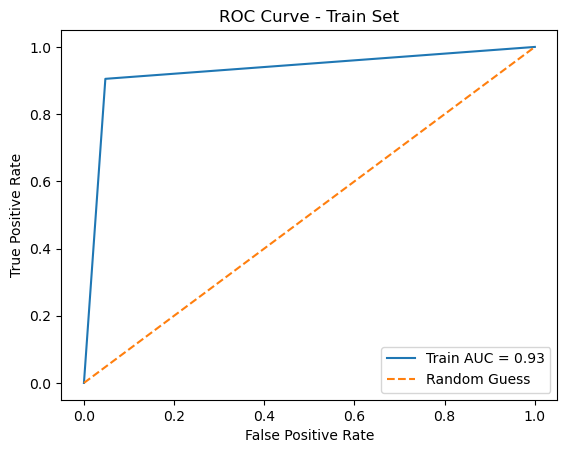

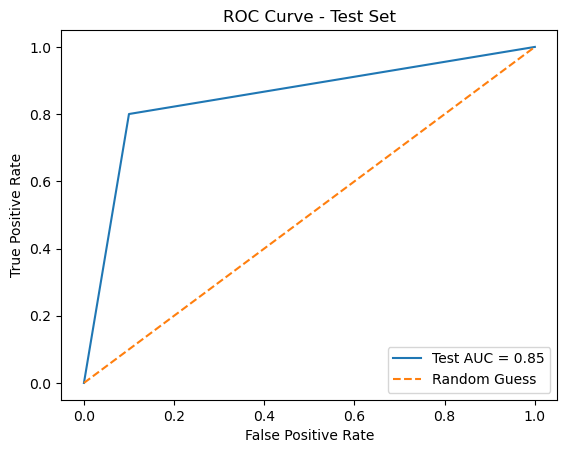

In [14]:
# One-Hot Encoding
encoder = OneHotEncoder(sparse=False)
y_train_encoded = encoder.fit_transform(y_train.values.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.values.reshape(-1, 1))
y_train_pred_encoded = encoder.transform(y_train_pred.reshape(-1, 1))
y_test_pred_encoded = encoder.transform(y_pred.reshape(-1, 1))

# Plot AUC Curve for Train Set
fpr_train, tpr_train, _ = roc_curve(y_train_encoded.ravel(), y_train_pred_encoded.ravel())
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure()
plt.plot(fpr_train, tpr_train, label=f'Train AUC = {roc_auc_train:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.title('ROC Curve - Train Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Plot AUC Curve for Test Set
fpr_test, tpr_test, _ = roc_curve(y_test_encoded.ravel(), y_test_pred_encoded.ravel())
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure()
plt.plot(fpr_test, tpr_test, label=f'Test AUC = {roc_auc_test:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.title('ROC Curve - Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

## Next steps for this model

1. Replace TF-IDF with more advanced embedding methods like Word2Vec, GloVe, or BERT to capture richer semantic relationships in the text. This can significantly enhance the model's ability to understand context and improve classification accuracy.
2. Incorporate Additional Features:
Include other features from the dataset, such as user ratings, review length, or business categories, to enhance model inputs